# K05_01 – Logistische Regression mit Iris-Daten

## Lernziele
- logistische Regression auf einen bekannten Datensatz anwenden
- Mehrklassenklassifikation in `scikit-learn` kennenlernen
- den Einfluss der Merkmalswahl auf die Modellgüte erkennen
- Accuracy und Konfusionsmatrix interpretieren

## 1. Bibliotheken importieren und Daten laden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = [target_names[i] for i in y]

print(df.head())
print("\nShape von X:", X.shape)
print("Shape von y:", y.shape)
print("Klassen:", target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Shape von X: (150, 4)
Shape von y: (150,)
Klassen: ['setosa' 'versicolor' 'virginica']


## 2. Zwei Merkmale visualisieren
Zur Übersicht betrachten wir zunächst zwei Merkmale:
- Petal length
- Petal width

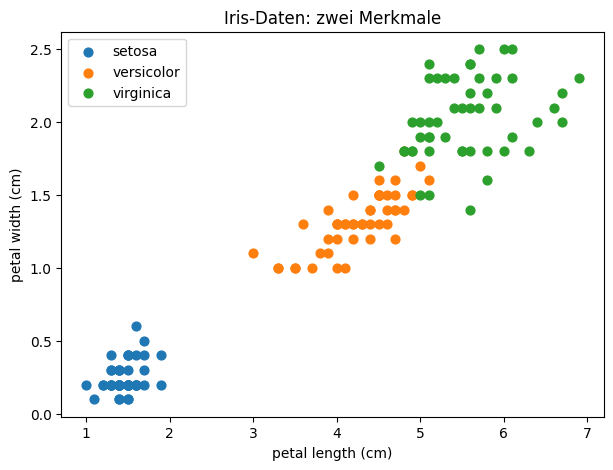

In [3]:
plt.figure(figsize=(7, 5))
for klasse, name in enumerate(target_names):
    plt.scatter(
        X[y == klasse, 2],
        X[y == klasse, 3],
        label=name,
        s=40
    )

plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title("Iris-Daten: zwei Merkmale")
plt.legend()
plt.show()

## 3. Modell mit allen vier Merkmalen trainieren

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf_all = LogisticRegression(max_iter=300)
clf_all.fit(X_train, y_train)

y_pred_all = clf_all.predict(X_test)

acc_all = accuracy_score(y_test, y_pred_all)
cm_all = confusion_matrix(y_test, y_pred_all)

print("Accuracy mit 4 Merkmalen:", round(acc_all, 3))
print("\nKonfusionsmatrix:\n", cm_all)

Accuracy mit 4 Merkmalen: 0.933

Konfusionsmatrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


## 4. Modell nur mit zwei Merkmalen trainieren
Jetzt verwenden wir nur zwei Merkmale:
- Petal length
- Petal width

In [5]:
X_two = X[:, [2, 3]]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.3, random_state=42, stratify=y
)

clf_two = LogisticRegression(max_iter=300)
clf_two.fit(X_train2, y_train2)

y_pred_two = clf_two.predict(X_test2)

acc_two = accuracy_score(y_test2, y_pred_two)
cm_two = confusion_matrix(y_test2, y_pred_two)

print("Accuracy mit 2 Merkmalen:", round(acc_two, 3))
print("\nKonfusionsmatrix:\n", cm_two)

Accuracy mit 2 Merkmalen: 0.933

Konfusionsmatrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]


## 5. Vergleich der Ergebnisse

In [6]:
print(f"Accuracy mit 4 Merkmalen: {acc_all:.3f}")
print(f"Accuracy mit 2 Merkmalen: {acc_two:.3f}")

Accuracy mit 4 Merkmalen: 0.933
Accuracy mit 2 Merkmalen: 0.933


## 6. Kleine Übung

**Aufgabe 1:**  
Vergleichen Sie die beiden Accuracy-Werte.

**Aufgabe 2:**  
Schreiben Sie in 2–3 Sätzen:
- Warum können 4 Merkmale besser sein als nur 2?
- Warum können trotzdem schon 2 gut gewählte Merkmale eine brauchbare Klassifikation ermöglichen?

### Lösung Aufgabe 1:
Beide Modelle (mit 4 und mit 2 Merkmalen) erreichen eine Accuracy von 0.933. In diesem speziellen Fall zeigen die petal length und petal width Merkmale eine ebenso gute Klassifikationsleistung wie alle vier Merkmale zusammen.

### Lösung Aufgabe 2:
**Warum können 4 Merkmale besser sein als nur 2?**
Mehr Merkmale können potenziell mehr Informationen über die Daten liefern und komplexere Muster erfassen. Dies kann besonders bei Datensätzen hilfreich sein, bei denen die Klassen nicht linear trennbar sind oder wenn relevante Informationen über mehrere Merkmale verteilt sind. Eine höhere Anzahl an Merkmalen kann die Fähigkeit des Modells verbessern, subtile Unterschiede zwischen den Klassen zu erkennen und somit die Modellgüte steigern.

**Warum können trotzdem schon 2 gut gewählte Merkmale eine brauchbare Klassifikation ermöglichen?**
Wie im Iris-Datensatz zu sehen, können auch nur zwei gut gewählte Merkmale eine sehr effektive Klassifikation ermöglichen, wenn diese Merkmale stark diskriminierend sind und die Klassen bereits gut voneinander trennen. Bei den Iris-Blüten sind die 'petal length' und 'petal width' sehr aussagekräftig, da sie klare Unterschiede zwischen den Arten aufweisen. In solchen Fällen ist die zusätzliche Komplexität und der Rechenaufwand durch weitere Merkmale möglicherweise nicht notwendig oder bringt keinen signifikanten Mehrwert für die Modellleistung.

In [7]:
# TODO: Optional können Sie noch eine weitere 2-Merkmal-Kombination testen.
# Beispiel:
# X_alt = X[:, [0, 1]]
# ...

### Optionale Übung: Modell mit 'sepal length' und 'sepal width' trainieren

In [8]:
# Verwenden Sie jetzt 'sepal length' (Merkmal 0) und 'sepal width' (Merkmal 1)
X_alt = X[:, [0, 1]]

X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_alt, y, test_size=0.3, random_state=42, stratify=y
)

clf_alt = LogisticRegression(max_iter=300)
clf_alt.fit(X_train_alt, y_train_alt)

y_pred_alt = clf_alt.predict(X_test_alt)

acc_alt = accuracy_score(y_test_alt, y_pred_alt)
cm_alt = confusion_matrix(y_test_alt, y_pred_alt)

print("Accuracy mit 'sepal length' und 'sepal width':", round(acc_alt, 3))
print("\nKonfusionsmatrix:\n", cm_alt)

Accuracy mit 'sepal length' und 'sepal width': 0.733

Konfusionsmatrix:
 [[15  0  0]
 [ 0  9  6]
 [ 0  6  9]]


## 7. Reflexion
- Warum ist Iris hier ein Mehrklassenproblem?
Insgesamt 3 Irisklassen
- Welche Rolle spielt `max_iter`?

- Was zeigt die Konfusionsmatrix zusätzlich zur Accuracy?


### Reflexion: Antworten

- **Warum ist Iris hier ein Mehrklassenproblem?**
  Das Iris-Problem ist ein Mehrklassenproblem, weil es drei verschiedene Zielklassen (Iris-Arten: Setosa, Versicolor, Virginica) gibt. Ein Klassifikationsmodell muss in der Lage sein, jede Eingabe einer dieser drei diskreten Klassen zuzuordnen. Dies unterscheidet es von Binärklassifikationsproblemen, die nur zwei Klassen haben.

- **Welche Rolle spielt `max_iter`?**
  `max_iter` in der `LogisticRegression`-Klasse gibt die maximale Anzahl von Iterationen an, die der Optimierungsalgorithmus ausführen darf, um die Konvergenz der Logistischen Regression zu erreichen. Wenn der Algorithmus nicht innerhalb dieser Anzahl von Iterationen konvergiert, wird er beendet. Ein zu kleiner Wert kann dazu führen, dass das Modell nicht vollständig trainiert wird und möglicherweise nicht die optimale Lösung findet, während ein zu großer Wert unnötig Rechenzeit verbrauchen kann, wenn das Modell bereits konvergiert hat.

- **Was zeigt die Konfusionsmatrix zusätzlich zur Accuracy?**
  Die Konfusionsmatrix zeigt detailliert, wie gut ein Klassifikationsmodell für jede einzelne Klasse abschneidet. Während die Accuracy nur einen Gesamtprozentsatz der korrekten Vorhersagen liefert, visualisiert die Konfusionsmatrix die Anzahl der:
    - **True Positives (TP):** Korrekt als Klasse X vorhergesagte Instanzen der Klasse X.
    - **True Negatives (TN):** Korrekt als Nicht-Klasse X vorhergesagte Instanzen, die auch nicht Klasse X sind.
    - **False Positives (FP):** Falsch als Klasse X vorhergesagte Instanzen, die tatsächlich einer anderen Klasse angehören (Typ-I-Fehler).
    - **False Negatives (FN):** Falsch als Nicht-Klasse X vorhergesagte Instanzen, die tatsächlich Klasse X sind (Typ-II-Fehler).
  Dies ermöglicht eine tiefere Analyse der Modellfehler und hilft zu verstehen, welche Klassen miteinander verwechselt werden.